In [1]:
import joblib
import numpy as np
import matplotlib.pyplot as plt


In [3]:
data_dir = "/home/tomren/tmp/"

data_tt = joblib.load(f"{data_dir}/bkg_muon_tt.joblib")
data_bb = joblib.load(f"{data_dir}/bkg_muon_bb.joblib")
data_ew = joblib.load(f"{data_dir}/bkg_muon_ew.joblib")

In [56]:
def convert_p(data):
    p_combined = []
    for line in data:
        if line[0] == "n" :
            continue
        else:
            p_xyz = np.array(line)[[4, 5, -6]]
            p_abs = np.linalg.norm(p_xyz)
            eta = np.arctanh(abs(p_xyz[0])/p_abs)
            pT = np.linalg.norm(p_xyz[1:])
            p_combined.append([p_abs, eta, pT])

    return np.array(p_combined)

eta_max = 1.35
eta_min = 0.8

cross_section_tt = 597
cross_section_bb = 3.632e06
cross_section_ew = 7504


In [57]:
p_tt = convert_p(data_tt)
p_bb = convert_p(data_bb)
p_ew = convert_p(data_ew)

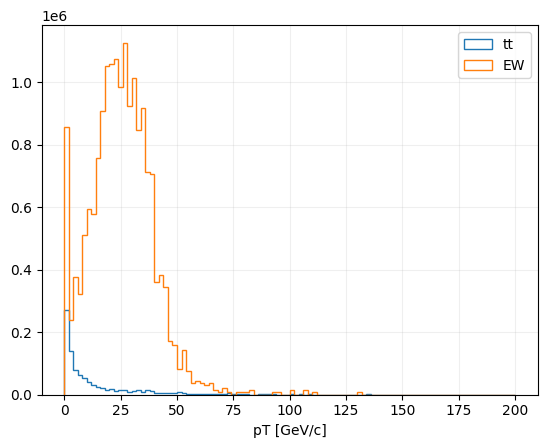

In [58]:
x = p_tt[:,2][(p_tt[:,1]>eta_min)&(p_tt[:,1]<eta_max)]*0.001
plt.hist(x, bins=100, range=(0,200), histtype="step", label="tt", weights=cross_section_tt*np.ones(len(x)));
# x = p_bb[:,2][(p_bb[:,1]>eta_min)&(p_bb[:,1]<eta_max)]*0.001
# plt.hist(x, bins=100, range=(0,200), histtype="step", label="bb", weights=cross_section_bb*np.ones(len(x)));
x = p_ew[:,2][(p_ew[:,1]>eta_min)&(p_ew[:,1]<eta_max)]*0.001
plt.hist(x, bins=100, range=(0,200), histtype="step", label="EW", weights=cross_section_ew*np.ones(len(x)));
plt.grid(which="both", alpha=0.2)
plt.xlabel("pT [GeV/c]")
plt.legend()
# plt.yscale("log")
